In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# CONVERGENCE
## Persamaan Parabolik: Persamaan Panas (Heat Equation)

Sekarang kita menggabungkan apa yang telah dipelajari sebelumnya mengenai diskretisasi ruang (untuk boundary value problem) dengan diskretisasi waktu (untuk initial value problem). Kombinasi ini penting karena banyak persamaan fisika bergantung pada ruang dan waktu secara bersamaan.

Jenis persamaan pertama yang akan kita pelajari adalah persamaan parabolik, dengan fokus pada persamaan panas:

$$
u_t = \kappa u_{xx}
$$

Persamaan ini menyatakan bahwa perubahan suhu terhadap waktu ($u_t$) bergantung pada kelengkungan distribusi suhu terhadap ruang ($u_{xx}$). Konstanta $\kappa$ adalah koefisien difusi yang mengatur seberapa cepat panas menyebar.

Selain persamaan utama, kita juga memerlukan kondisi batas:

$$\begin{aligned}
u(0, t) &= g_0(t) \quad \text{untuk } t > 0 \\
u(1, t) &= g_1(t) \quad \text{untuk } t > 0
\end{aligned}$$

yang disebut kondisi batas Dirichlet, karena nilai fungsi ditentukan langsung di batas domain. Selain itu, diberikan juga kondisi awal:

$$
u(x, 0) = u_0(x)
$$

yang menyatakan distribusi awal suhu pada seluruh domain.

Di sini diasumsikan domain ruang adalah $\Omega = [0,1]$ dan waktu awal $t_0 = 0$.

Selanjutnya, domain ruang dan waktu didiskretisasi menjadi:

$$
x_i = i \Delta x, \quad t_n = n \Delta t
$$

sehingga fungsi kontinu $u(x,t)$ didekati oleh solusi numerik:

$$
U_i^n \approx u(x_i, t_n)
$$

---

## Diskretisasi Forward Euler (Eksplisit)

Sebagai pendekatan pertama, kita gunakan metode Forward Euler untuk waktu dan beda hingga terpusat orde dua untuk ruang.

Turunan waktu didekati dengan:

$$
u_t \approx \frac{U_i^{n+1} - U_i^n}{\Delta t}
$$

Sedangkan turunan kedua terhadap ruang didekati dengan:

$$
u_{xx} \approx \frac{U^n_{i-1} - 2U^n_i + U^n_{i+1}}{\Delta x^2}
$$

Substitusi ke persamaan panas menghasilkan:

$$
\frac{U^{n+1}_i - U^n_i}{\Delta t} = \frac{1}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$

Kemudian dikalikan $\Delta t$:

$$
U^{n+1}_i - U^n_i = \frac{\Delta t}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$

sehingga diperoleh bentuk update:

$$
U^{n+1}_i = U^n_i + \frac{\Delta t}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$

Metode ini disebut eksplisit karena nilai $U^{n+1}$ dapat langsung dihitung dari nilai pada waktu sebelumnya.

---

## Interpretasi sebagai Initial Value Problem

Bentuk di atas dapat ditulis sebagai:

$$
U^{n+1}_i = U^n_i + \Delta t f(t_n, U^n_i)
$$

dengan:

$$
f(t_n, U^n_i) = \frac{1}{\Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1})
$$

Artinya, seluruh pengaruh ruang dimasukkan ke dalam fungsi $f$, sehingga sistem ini dapat dianalisis seperti metode numerik untuk ODE (initial value problem).

---

## Metode Crank-Nicholson

Metode Crank-Nicholson menggunakan pendekatan rata-rata (trapesium) antara waktu $n$ dan $n+1$:

$$
\frac{U^{n+1}_i - U^n_i}{\Delta t} = \frac{1}{2} (f(U^n_i) + f(U^{n+1}_i))
$$

Substitusi bentuk $f$ menghasilkan:

$$
\frac{U^{n+1}_i - U^n_i}{\Delta t} =
\frac{1}{2} \frac{U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1}}{\Delta x^2}
$$

Kalikan dengan $\Delta t$:

$$
U^{n+1}_i - U^n_i =
\frac{\Delta t}{2 \Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1})
$$

Sehingga:

$$
U^{n+1}_i = U^n_i + \frac{\Delta t}{2 \Delta x^2} (U^n_{i-1} - 2 U^n_i + U^n_{i+1} + U^{n+1}_{i-1} - 2 U^{n+1}_i + U^{n+1}_{i+1})
$$

Metode ini bersifat implisit karena melibatkan nilai pada waktu $n+1$, sehingga harus diselesaikan sebagai sistem persamaan.

---

## Bentuk Sistem Linear

Dengan mendefinisikan:

$$
r = \frac{\Delta t}{2 \Delta x^2}
$$

dan menyusun ulang persamaan, diperoleh:

$$
- r U^{n+1}_{i-1} + (1 + 2r) U^{n+1}_i - r U^{n+1}_{i+1}
= r U^{n}_{i-1} + (1 - 2r) U^{n}_{i} + r U^{n}_{i+1}
$$

Persamaan ini menunjukkan bahwa setiap titik bergantung pada tetangga kiri dan kanan, sehingga membentuk sistem matriks tridiagonal.

---

## Bentuk Matriks

Sistem ini dapat ditulis sebagai:

$$
A U^{n+1} = f(t_n, U^n)
$$

dengan matriks:

$$
A =
\begin{bmatrix}
1+2r & -r \\
-r & 1+2r & -r \\
& -r & 1+2r & -r \\
& & \ddots & \ddots & \ddots \\
& & & -r & 1+2r & -r \\
& & & & -r & 1+2r
\end{bmatrix}
$$

dan ruas kanan:

$$
f(t_n, U^{n}) =
\begin{bmatrix}
r (g_0(t_n) + g_0(t_{n+1})) + (1 - 2r) U^n_1 + r U^n_2 \\
r U^n_1 + (1-2r) U^n_2 + r U^n_3 \\
r U^n_2 + (1-2r) U^n_3 + r U^n_4 \\
\vdots \\
r U^n_{m-2} + (1-2r) U^n_{m-1} + r U^n_m \\
r U^n_{m-1} + (1-2r) U^n_m + r(g_1(t_n) + g_1(t_{n+1}))
\end{bmatrix}
$$

Bentuk ini menunjukkan bahwa pada setiap langkah waktu, kita harus menyelesaikan sistem persamaan linear. Karena matriksnya tridiagonal, sistem ini dapat diselesaikan secara efisien menggunakan algoritma khusus seperti metode Thomas.

Dari pembahasan kita mengenai metode iteratif, sistem tridiagonal yang muncul pada metode Crank-Nicholson dapat diselesaikan dalam $\mathcal{O}(m)$ operasi, misalnya menggunakan algoritma Thomas. Hal ini membuat metode Crank-Nicholson secara komputasi sama efisiennya dengan metode eksplisit sebelumnya. Keunggulan utama metode implisit ini adalah kemampuannya menggunakan langkah waktu ($\Delta t$) yang lebih besar tanpa melanggar kestabilan, karena metode ini lebih stabil terutama untuk sistem yang bersifat *stiff*. Dalam konteks ini, persamaan panas dapat dipandang sebagai sistem ODE yang kaku (*stiff system*), karena perubahan cepat dapat terjadi pada skala ruang yang kecil.

---

## Local Truncation Error

Galat pemotongan lokal (*local truncation error*) $\tau^n$ dihitung dengan cara yang sama seperti sebelumnya, tetapi sekarang melibatkan turunan terhadap waktu dan ruang. Prosedurnya adalah dengan mensubstitusikan solusi eksak $u(x,t)$ ke dalam skema diskret, lalu menggunakan ekspansi Taylor untuk melihat suku galat dominan.

Sebagai contoh, untuk metode eksplisit (Forward Euler), kita definisikan:

$$
\tau^n_i = \tau(x_i, t_n) =
\frac{u(x, t + \Delta t) - u(x, t)}{\Delta t}
- \frac{1}{\Delta x^2} (u(x - \Delta x, t) - 2 u(x, t) + u(x + \Delta x, t))
$$

Untuk menghitungnya, kita gunakan ekspansi Taylor:

$$\begin{aligned}
u(x, t + \Delta t) &= u(x,t) + u_t(x,t)\Delta t + \frac{\Delta t^2}{2} u_{tt}(x,t) + \frac{\Delta t^3}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^4) \\
u(x \pm \Delta x, t) &= u(x,t) \pm \Delta x u_x(x,t) + \frac{\Delta x^2}{2} u_{xx}(x,t) \pm \frac{\Delta x^3}{6} u_{xxx}(x,t) + \frac{\Delta x^4}{24} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5)
\end{aligned}$$

Substitusi ekspansi ini ke dalam definisi $\tau(x,t)$ dilakukan langkah demi langkah. Untuk bagian waktu:

$$
\frac{u(x,t+\Delta t) - u(x,t)}{\Delta t}
= u_t(x,t) + \frac{\Delta t}{2} u_{tt}(x,t) + \frac{\Delta t^2}{6} u_{ttt}(x,t) + \mathcal{O}(\Delta t^3)
$$

Sedangkan untuk bagian ruang:

$$
u(x-\Delta x,t) - 2u(x,t) + u(x+\Delta x,t)
$$

Jika kita jumlahkan ekspansi Taylor kiri dan kanan, suku ganjil (yang mengandung $u_x$, $u_{xxx}$) saling menghilangkan, sehingga diperoleh:

$$
= \Delta x^2 u_{xx}(x,t) + \frac{\Delta x^4}{12} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^5)
$$

Kemudian dibagi dengan $\Delta x^2$:

$$
\frac{1}{\Delta x^2}(...) = u_{xx}(x,t) + \frac{\Delta x^2}{12} u_{xxxx}(x,t) + \mathcal{O}(\Delta x^3)
$$

Sehingga galat truncation menjadi:

$$
\begin{aligned}
\tau(x,t)
&= \left[u_t + \frac{\Delta t}{2} u_{tt} + \frac{\Delta t^2}{6} u_{ttt} \right]
- \left[u_{xx} + \frac{\Delta x^2}{12} u_{xxxx} \right] \\
&= u_t - u_{xx}
+ \frac{\Delta t}{2} u_{tt}
+ \frac{\Delta t^2}{6} u_{ttt}
- \frac{\Delta x^2}{12} u_{xxxx}
+ \mathcal{O}(\Delta t^3, \Delta x^4)
\end{aligned}
$$

Karena solusi eksak memenuhi persamaan panas $u_t = u_{xx}$, maka suku $u_t - u_{xx}$ hilang, sehingga:

$$
\tau(x,t) =
\frac{\Delta t}{2} u_{tt}
+ \frac{\Delta t^2}{6} u_{ttt}
- \frac{\Delta x^2}{12} u_{xxxx}
+ \mathcal{O}(\Delta t^3, \Delta x^4)
$$

Untuk menyederhanakan, kita gunakan turunan dari persamaan panas:

$$
u_t = u_{xx} \Rightarrow u_{tt} = (u_t)_t = (u_{xx})_t = (u_t)_{xx} = u_{xxxx}
$$

Dengan asumsi solusi cukup halus, maka:

$$
\tau(x,t) =
\left( \frac{\Delta t}{2} - \frac{\Delta x^2}{12} \right) u_{xxxx}
+ \mathcal{O}(\Delta t^2, \Delta x^4)
$$

Dari sini terlihat bahwa galat bergantung pada $\Delta t$ secara orde pertama dan $\Delta x$ secara orde kedua, sehingga metode eksplisit ini adalah orde satu dalam waktu dan orde dua dalam ruang, serta bersifat konsisten karena $\tau \to 0$ saat $\Delta t, \Delta x \to 0$.

Untuk metode Crank-Nicholson, dengan prosedur serupa, dapat ditunjukkan bahwa:

$$
\tau(x,t) = \mathcal{O}(\Delta t^2, \Delta x^2)
$$

yang berarti metode ini orde dua baik dalam waktu maupun ruang.

---

## Method of Lines

Metode *method of lines* adalah pendekatan di mana diskretisasi ruang dan waktu dilakukan secara terpisah. Pertama, turunan ruang didiskretisasi sehingga diperoleh sistem ODE terhadap waktu.

Sebagai contoh, dari persamaan panas diperoleh:

$$
U_i'(t) = \frac{1}{\Delta x^2} (U_{i-1}(t) - 2 U_i(t) + U_{i+1}(t))
$$

yang merupakan sistem ODE (semi-diskret), dan kemudian dapat diselesaikan menggunakan metode ODE seperti Forward Euler atau Crank-Nicholson.

---

## Stability

Dalam perspektif method of lines, kestabilan metode bergantung pada apakah:

$$
z = \Delta t \lambda
$$

berada dalam daerah stabilitas metode ODE yang digunakan.

Untuk persamaan panas dengan diskretisasi beda hingga orde dua, nilai eigen dari matriks ruang adalah:

$$
\lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1)
$$

Ketika $\Delta x \to 0$, nilai eigen menjadi sangat besar (negatif), yang menunjukkan bahwa sistem menjadi semakin *stiff*.

Nilai eigen terbesar (paling negatif) adalah:

$$
\lambda = -\frac{4}{\Delta x^2}
$$

Sehingga:

$$
z = \Delta t \lambda = -\frac{4 \Delta t}{\Delta x^2}
$$

Untuk metode eksplisit, syarat stabilitas adalah:

$$
|1 + \Delta t \lambda| \leq 1
$$

Substitusi $\lambda$ menghasilkan:

$$
|1 - \frac{4 \Delta t}{\Delta x^2}| \leq 1
$$

yang memberikan syarat:

$$
\frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}
$$

Ini menunjukkan bahwa langkah waktu harus cukup kecil dibandingkan kuadrat langkah ruang agar metode tetap stabil.

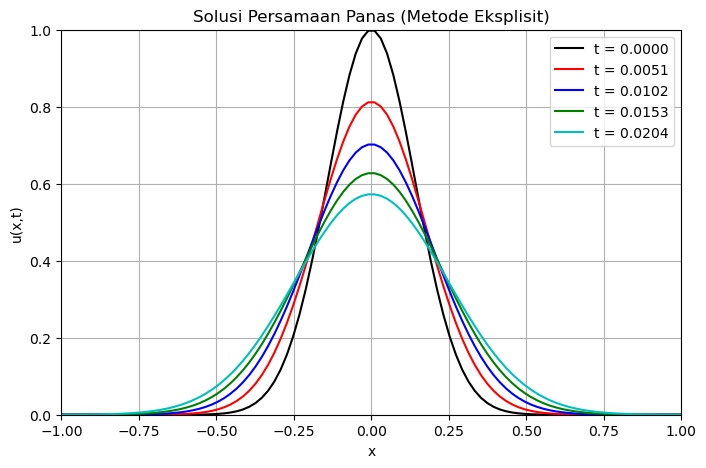

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Diskretisasi Ruang (Spatial Grid)
# =========================
m = 100  # jumlah titik grid
x = np.linspace(-1.0, 1.0, m)  # domain [-1, 1]
delta_x = 2.0 / (m - 1.0)  # jarak antar titik

# =========================
# Diskretisasi Waktu (Time Grid)
# =========================
# Dipilih delta_t = 0.5 * delta_x^2 agar memenuhi syarat stabilitas:
# Δt / Δx^2 ≤ 1/2
delta_t = 0.5 * delta_x**2
N = 101  # jumlah langkah waktu
t = np.arange(0.0, N * delta_t, delta_t)

# =========================
# Inisialisasi Solusi
# =========================
U = np.zeros((N + 1, m))

# Kondisi awal (initial condition)
# Distribusi awal berbentuk Gaussian
U[0, :] = np.exp(-x**2 / 0.2**2)

# Kondisi batas (boundary conditions)
g_0 = lambda t: 0.0  # batas kiri
g_1 = lambda t: 0.0  # batas kanan

# =========================
# Iterasi Waktu (Time Stepping)
# =========================
for n in range(len(t)):
    for i in range(1, m - 1):
        # Skema Forward Euler + beda hingga pusat
        U[n+1, i] = U[n, i] + (delta_t / delta_x**2) * (
            U[n, i-1] - 2.0 * U[n, i] + U[n, i+1]
        )

    # Penanganan batas kiri (i = 0)
    U[n+1, 0] = U[n, 0] + (delta_t / delta_x**2) * (
        g_0(t[n]) - 2.0 * U[n, 0] + U[n, 1]
    )

    # Penanganan batas kanan (i = m-1)
    U[n+1, -1] = U[n, -1] + (delta_t / delta_x**2) * (
        U[n, -2] - 2.0 * U[n, -1] + g_1(t[n])
    )

# =========================
# Visualisasi Hasil
# =========================
colors = ['k', 'r', 'b', 'g', 'c']

plt.figure(figsize=(8,5))
for i, n in enumerate((0, 25, 50, 75, 100)):
    plt.plot(x, U[n, :], colors[i], label=f't = {t[n]:.4f}')

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Solusi Persamaan Panas (Metode Eksplisit)")
plt.xlim([-1, 1])
plt.ylim([0.0, 1.0])
plt.legend()
plt.grid(True)
plt.show()

## Stabilitas Metode Crank-Nicholson

Untuk metode **Crank-Nicholson**, kita mengetahui bahwa metode trapezoidal (trapesium) bersifat *absolutely stable* (stabil mutlak), sehingga secara teori kita dapat memilih nilai $\Delta t$ (langkah waktu) sebesar apa pun tanpa menyebabkan solusi menjadi tidak stabil, karena metode ini memiliki daerah stabilitas yang mencakup seluruh sumbu real negatif.

Sifat ini berasal dari bentuk diskretisasi metode Crank-Nicholson yang merupakan rata-rata antara metode eksplisit dan implisit:
$$
\frac{U_i^{n+1} - U_i^n}{\Delta t} = \frac{1}{2} \left( D_x^2 U_i^n + D_x^2 U_i^{n+1} \right),
$$
di mana
$$
D_x^2 U_i^n = \frac{U_{i-1}^n - 2U_i^n + U_{i+1}^n}{\Delta x^2}
$$
adalah aproksimasi turunan kedua terhadap ruang yang diperoleh dari ekspansi Taylor orde dua. Bentuk ini menunjukkan bahwa metode ini "menyeimbangkan" kontribusi waktu sekarang ($n$) dan waktu berikutnya ($n+1$), sehingga menghasilkan kestabilan yang lebih baik dibanding metode eksplisit yang hanya bergantung pada waktu $n$.

Jika persamaan tersebut disusun ulang, kita akan memperoleh sistem linear:
$$
\left(I - \frac{\Delta t}{2} D_x^2 \right) U^{n+1} = \left(I + \frac{\Delta t}{2} D_x^2 \right) U^n,
$$
yang menunjukkan bahwa solusi pada waktu berikutnya diperoleh dengan menyelesaikan sistem persamaan linear, inilah yang menjadi ciri khas metode implisit.

Namun demikian, jika $\Delta t$ dipilih terlalu besar, maka meskipun solusi tetap stabil (tidak divergen), akurasi solusi dapat menurun. Hal ini terjadi karena error truncation dalam waktu tetap bergantung pada $\Delta t$, yaitu:
$$
\tau = \mathcal{O}(\Delta t^2, \Delta x^2),
$$
yang berarti semakin besar $\Delta t$, semakin besar pula error yang dihasilkan, meskipun secara teoritis metode tetap stabil.

Oleh karena itu, dalam praktiknya kita tetap perlu berhati-hati dalam memilih $\Delta t$. Secara umum, kita dapat memilih:
$$
\Delta t = \mathcal{O}(\Delta x),
$$
yang berarti langkah waktu dipilih sebanding dengan langkah ruang agar keseimbangan error antara diskretisasi waktu dan ruang tetap terjaga, sehingga diperoleh solusi yang cukup akurat tanpa mengorbankan efisiensi komputasi.

delta_x = 0.020202020202020204
delta_t = 0.010101010101010102


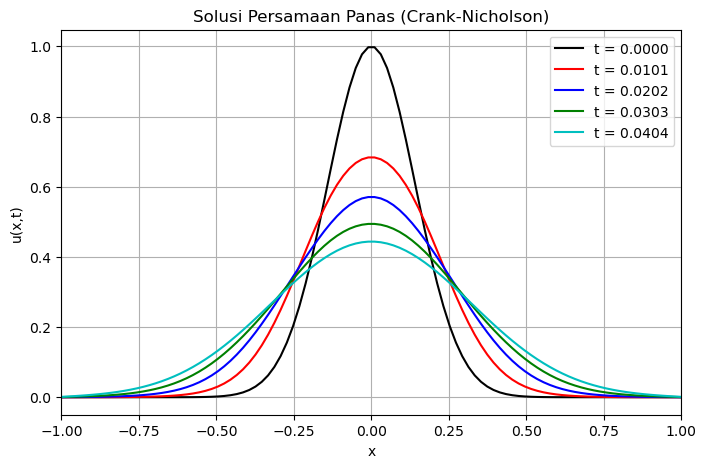

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg

# =========================
# Diskretisasi Ruang
# =========================
m = 100
x = np.linspace(-1.0, 1.0, m)
delta_x = 2.0 / (m - 1.0)
print(f"delta_x = {delta_x}")

# =========================
# Diskretisasi Waktu
# =========================
# Dipilih Δt = C * Δx (berdasarkan pertimbangan akurasi)
C = 0.5
delta_t = C * delta_x
t = np.arange(0.0, 1.0, delta_t)
N = len(t)
print(f"delta_t = {delta_t}")

# =========================
# Inisialisasi Solusi
# =========================
U = np.zeros((N + 1, m))

# Kondisi awal (Gaussian)
U[0, :] = np.exp(-x**2 / 0.2**2)

# Kondisi batas
g_0 = lambda t: 0.0
g_1 = lambda t: 0.0

# =========================
# Pembentukan Matriks
# =========================
# r = Δt / (2 Δx^2)
r = np.ones(m) * delta_t / (2.0 * delta_x**2)

# Matriks A (bagian implisit, waktu n+1)
A = sparse.spdiags(
    [-r, 1.0 + 2.0 * r, -r],
    [-1, 0, 1],
    m, m
).tocsr()

# Matriks B (bagian eksplisit, waktu n)
B = sparse.spdiags(
    [r, 1.0 - 2.0 * r, r],
    [-1, 0, 1],
    m, m
).tocsr()

# =========================
# Iterasi Waktu
# =========================
for n in range(len(t) - 1):
    # Membentuk ruas kanan (right-hand side)
    b = B.dot(U[n, :])

    # Penyesuaian kondisi batas (karena metode implisit melibatkan waktu n dan n+1)
    b[0] += delta_t / (2.0 * delta_x**2) * (g_0(t[n]) + g_0(t[n+1]))
    b[-1] += delta_t / (2.0 * delta_x**2) * (g_1(t[n]) + g_1(t[n+1]))

    # Menyelesaikan sistem linear: A U^{n+1} = b
    U[n+1, :] = linalg.spsolve(A, b)

# =========================
# Visualisasi
# =========================
colors = ['k', 'r', 'b', 'g', 'c']

plt.figure(figsize=(8,5))
for i, n in enumerate((0, 1, 2, 3, 4)):
    plt.plot(x, U[n, :], colors[i], label=f't = {t[n]:.4f}')

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Solusi Persamaan Panas (Crank-Nicholson)")
plt.xlim([-1, 1])
plt.legend()
plt.grid(True)
plt.show()

## Stabilitas dengan Dua Parameter ($\Delta t$ dan $\Delta x$)

Hal ini menimbulkan pertanyaan tentang bagaimana kita menganalisis stabilitas ketika terdapat dua parameter yang berubah, yaitu $\Delta t$ (langkah waktu) dan $\Delta x$ (langkah ruang). Dalam konteks ini, hubungan keduanya menjadi penting karena keduanya muncul secara bersamaan dalam skema numerik, misalnya dalam bentuk rasio $\frac{\Delta t}{\Delta x^2}$ pada persamaan panas, yang sering menjadi parameter kunci dalam menentukan stabilitas metode eksplisit.

Metode *method of lines* membantu dengan memisahkan masalah menjadi dua bagian, yaitu diskretisasi ruang dan diskretisasi waktu. Secara matematis, kita terlebih dahulu mendiskretisasi turunan ruang, misalnya:
$$
u_{xx} \approx \frac{U_{i-1} - 2U_i + U_{i+1}}{\Delta x^2},
$$
yang diperoleh dari ekspansi Taylor di sekitar titik $x_i$ dengan menjumlahkan $u(x+\Delta x)$ dan $u(x-\Delta x)$ sehingga suku orde ganjil saling menghilangkan. Hasil diskretisasi ini kemudian menghasilkan sistem ODE:
$$
\frac{dU_i(t)}{dt} = \frac{1}{\Delta x^2}(U_{i-1}(t) - 2U_i(t) + U_{i+1}(t)),
$$
yang menunjukkan bahwa perubahan terhadap waktu bergantung pada interaksi titik tetangga di ruang.

Setelah itu, sistem ODE ini diselesaikan menggunakan metode numerik dalam waktu (misalnya Forward Euler atau Crank-Nicholson). Pendekatan ini sangat membantu karena kita dapat menganalisis stabilitas metode waktu secara terpisah dari diskretisasi ruang, misalnya dengan melihat apakah $\Delta t \lambda$ berada dalam daerah stabilitas metode ODE.

Namun, pendekatan ini tidak selalu memberikan gambaran yang lengkap. Hal ini disebabkan karena dalam analisis galat (error), beberapa suku dari aproksimasi ruang dan waktu dapat saling meniadakan (*cancel out*). Fenomena ini dapat dilihat dari ekspansi Taylor, misalnya:
$$
u(x,t+\Delta t) = u(x,t) + u_t \Delta t + \frac{\Delta t^2}{2} u_{tt} + \cdots
$$
dan
$$
u(x \pm \Delta x,t) = u(x,t) \pm \Delta x u_x + \frac{\Delta x^2}{2} u_{xx} + \cdots
$$

Ketika substitusi dilakukan menggunakan persamaan diferensial parsial (misalnya $u_t = u_{xx}$ pada persamaan panas), turunan waktu dan turunan ruang menjadi saling terkait. Dengan menurunkan terhadap waktu:
$$
u_{tt} = (u_t)_t = (u_{xx})_t = u_{xxxx},
$$
yang menunjukkan bahwa turunan waktu orde dua sebenarnya ekuivalen dengan turunan ruang orde empat.

Akibatnya, beberapa suku galat dari arah waktu dan ruang dapat saling menghilangkan atau justru memperkuat satu sama lain, tergantung pada bentuk skema numerik yang digunakan. Hal ini menjelaskan mengapa dalam beberapa metode, kombinasi tertentu dari $\Delta t$ dan $\Delta x$ dapat menghasilkan akurasi yang lebih baik dari yang diperkirakan secara terpisah.

Oleh karena itu, meskipun *method of lines* sangat berguna untuk memahami struktur masalah, kita tetap perlu mempertimbangkan interaksi antara diskretisasi waktu dan ruang secara bersamaan dalam analisis yang lebih menyeluruh, terutama ketika membahas stabilitas dan error numerik.

## Kekakuan (Stiffness) dan Persamaan Panas

Ingat kembali bahwa nilai eigen terbesar dari sistem diskret untuk $u_{xx} = f(x)$ berperilaku sebagai:
$$
\lambda_m = -\frac{4}{\Delta x^2},
$$
sedangkan nilai eigen terkecil mendekati:
$$
\lambda_1 \approx -\pi^2.
$$

Dengan demikian, rasio kekakuan (*stiffness ratio*) dapat dituliskan sebagai:
$$
\frac{\lambda_m}{\lambda_1} \approx \frac{4 \pi^2}{\Delta x^2} \rightarrow \infty \quad \text{ketika} \quad \Delta x \rightarrow 0,
$$
yang menunjukkan bahwa semakin kecil $\Delta x$, sistem menjadi semakin *stiff* karena perbedaan skala antar eigenvalue menjadi sangat besar.

Kekakuan ini muncul dari sifat alami persamaan panas, di mana dinamika sistem bekerja sangat cepat pada komponen frekuensi tinggi dan jauh lebih lambat pada komponen frekuensi rendah. Hal ini dapat dilihat melalui analisis Fourier terhadap solusi persamaan panas. 

Jika diasumsikan kondisi batas homogen $g_0(t) = g_1(t) = 0$, maka solusi dapat dituliskan sebagai deret Fourier:
$$
u(x,t) = \sum_{j=1}^{\infty} \hat{u}_j(t) \sin(j \pi x),
$$
yang berarti solusi diuraikan menjadi kombinasi mode sinusoidal dengan frekuensi berbeda.

Untuk menentukan koefisien $\hat{u}_j(t)$, kita substitusikan deret tersebut ke dalam PDE $u_t = u_{xx}$. Turunan ruang dari $\sin(j\pi x)$ menghasilkan:
$$
\frac{\partial^2}{\partial x^2} \sin(j\pi x) = -j^2 \pi^2 \sin(j\pi x),
$$
sehingga diperoleh persamaan diferensial biasa:
$$
\hat{u}_j'(t) = -j^2 \pi^2 \hat{u}_j(t).
$$

Persamaan ini dapat diselesaikan secara langsung sebagai:
$$
\hat{u}_j(t) = \hat{u}_j(0) e^{-j^2 \pi^2 t},
$$
yang menunjukkan bahwa setiap mode Fourier meluruh secara eksponensial terhadap waktu.

Dari sini terlihat bahwa komponen dengan frekuensi tinggi (nilai $j$ besar) memiliki faktor peluruhan $e^{-j^2 \pi^2 t}$ yang jauh lebih cepat dibandingkan komponen frekuensi rendah. Inilah yang menyebabkan sistem menjadi *stiff*, karena terdapat kombinasi dinamika cepat dan lambat dalam satu sistem.

Jika kita ingin menghitung solusi untuk waktu yang panjang (misalnya untuk melihat keadaan tunak/steady-state), maka penggunaan metode numerik dengan batasan stabilitas yang ketat (seperti metode eksplisit) akan menjadi tidak efisien, karena memaksa kita menggunakan $\Delta t$ yang sangat kecil akibat hubungan:
$$
\frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}.
$$

Sebaliknya, jika kita menggunakan metode yang tidak memiliki batasan stabilitas (seperti metode implisit atau Crank-Nicholson), maka kita dapat memilih $\Delta t$ lebih besar dan hanya perlu mempertimbangkan akurasi. Dalam hal ini, untuk menjaga keseimbangan error antara ruang dan waktu, sering dipilih:
$$
\Delta t \approx \Delta x,
$$
sehingga orde akurasi dalam ruang dan waktu tetap sebanding tanpa dibatasi oleh kondisi stabilitas.

# Konvergensi (Convergence)

Sekarang kita beralih ke pertanyaan bagaimana, untuk suatu titik $(x_i, t_n)$, pendekatan numerik kita $U_i^n$ dapat konvergen menuju solusi sebenarnya $u(x_i, t_n)$. Konvergensi di sini berarti bahwa nilai aproksimasi yang diperoleh dari metode numerik akan semakin mendekati solusi eksak ketika parameter diskretisasi diperkecil. Secara matematis, hal ini dapat dituliskan sebagai:
$$
U_i^n \to u(x_i, t_n) \quad \text{ketika } \Delta t, \Delta x \to 0
$$

Perlu diperhatikan bahwa kita memiliki dua parameter penting, yaitu $\Delta t$ (langkah waktu) dan $\Delta x$ (langkah ruang), yang keduanya ingin kita buat mendekati nol. Semakin kecil nilai kedua parameter ini, maka grid yang digunakan dalam simulasi akan semakin halus sehingga hasil perhitungan menjadi lebih akurat. Secara konseptual, domain kontinu dalam ruang dan waktu didiskretisasi menjadi titik-titik:
$$
x_i = i \Delta x, \quad t_n = n \Delta t
$$
Hal ini pada dasarnya menghasilkan suatu barisan grid dalam ruang dan waktu yang dinyatakan sebagai $(\Delta t_1, \Delta x_1)$, $(\Delta t_2, \Delta x_2)$, dan seterusnya, di mana setiap pasangan grid tersebut semakin mendekati nol.

Ternyata, hubungan antara $\Delta t$ dan $\Delta x$ yang harus dipenuhi agar konvergensi terjadi adalah sama dengan hasil kondisi stabilitas yang telah kita temukan sebelumnya. Hal ini muncul karena dalam banyak persamaan diferensial (misalnya persamaan difusi atau gelombang), diskretisasi waktu dan ruang saling berkaitan melalui parameter tertentu (misalnya rasio $\frac{\Delta t}{\Delta x^2}$). Jika hubungan ini tidak dipenuhi, maka solusi numerik bisa menjadi tidak stabil dan tidak akan mendekati solusi sebenarnya. Oleh karena itu, seringkali kriteria konvergensi dipandang sebagai aturan yang menghubungkan $\Delta t$ dan $\Delta x$, sehingga pada praktiknya kita hanya perlu mengontrol satu parameter saja sementara parameter lainnya mengikuti hubungan tersebut.

Selanjutnya, kita dapat menggeneralisasi hal ini ke dalam suatu kelas metode numerik yang dapat dituliskan sebagai:

$$
U^{n+1} = B(\Delta t) U^n + b^n(\Delta t)
$$

Bentuk ini sebenarnya berasal dari diskretisasi umum persamaan diferensial parsial atau biasa, di mana turunan waktu didekati dengan skema beda hingga, lalu semua komponen ruang dikumpulkan ke dalam bentuk matriks. Dengan kata lain, sistem kontinu diubah menjadi sistem aljabar linear.

dengan $B(\Delta t) \in \mathbb{R}^{m \times m}$ pada grid dengan $\Delta x = \frac{1}{m + 1}$ dan $b^n(\Delta t) \in \mathbb{R}^m$. Hubungan $\Delta x = \frac{1}{m+1}$ diperoleh dari pembagian domain (misalnya interval $[0,1]$) menjadi $m$ titik interior, sehingga semakin besar $m$, semakin kecil $\Delta x$ dan grid semakin rapat.

Bentuk ini menunjukkan bahwa solusi pada waktu berikutnya ($U^{n+1}$) diperoleh dari kombinasi linear solusi sebelumnya ($U^n$) melalui matriks $B(\Delta t)$, serta tambahan kontribusi dari $b^n(\Delta t)$ yang biasanya berasal dari sumber atau kondisi batas. Matriks $B(\Delta t)$ sering disebut sebagai *operator propagasi*, karena mengatur bagaimana solusi berkembang dari waktu ke waktu.

Di sini, kita membiarkan $\Delta t \to 0$ dan menentukan $\Delta x$ dari hubungan stabilitas atau akurasi antara $\Delta t$ dan $\Delta x$. Dengan kata lain, pemilihan grid ruang tidak dilakukan secara bebas, tetapi harus mengikuti hubungan tertentu agar metode tetap stabil sekaligus menghasilkan solusi yang konvergen menuju solusi eksak. Secara praktis, ini berarti bahwa dalam simulasi numerik kita sering memilih $\Delta t$ terlebih dahulu, kemudian $\Delta x$ ditentukan agar memenuhi syarat stabilitas tersebut.

Sebagai contoh, metode Forward Euler yang telah diperkenalkan sebelumnya dapat dituliskan sebagai:

$$
U^{n+1} = U^n + \Delta t A U^n
$$

Persamaan ini diperoleh dari pendekatan turunan waktu menggunakan beda maju (forward difference), yaitu:

$$
\frac{u^{n+1} - u^n}{\Delta t} \approx \frac{\partial u}{\partial t}
$$

Jika kita misalkan persamaan diferensialnya berbentuk:

$$
\frac{\partial u}{\partial t} = A u
$$

maka dengan mengganti turunan tersebut ke dalam skema beda hingga diperoleh:

$$
\frac{U^{n+1} - U^n}{\Delta t} = A U^n
$$

yang kemudian dapat disusun ulang menjadi:

$$
U^{n+1} = U^n + \Delta t A U^n
$$

Sehingga jika dibandingkan dengan bentuk umum:

$$
U^{n+1} = B(\Delta t) U^n + b^n(\Delta t)
$$

diperoleh:

$$
B(\Delta t) = I + \Delta t A, \quad b^n(\Delta t) = 0
$$

di mana $A$ adalah matriks tridiagonal yang berasal dari diskretisasi turunan orde dua menggunakan metode beda hingga terpusat. Bentuk tridiagonal ini muncul karena setiap titik hanya berinteraksi dengan titik tetangganya di kiri dan kanan.

Selanjutnya, untuk metode Crank-Nicholson, kita mulai dari pendekatan turunan waktu yang menggunakan rata-rata antara waktu ke-$n$ dan $n+1$:

$$
\frac{U^{n+1} - U^n}{\Delta t} = \frac{1}{2} \left( A U^n + A U^{n+1} \right)
$$

Kemudian kita kalikan kedua ruas dengan $\Delta t$:

$$
U^{n+1} - U^n = \frac{\Delta t}{2} A U^n + \frac{\Delta t}{2} A U^{n+1}
$$

Selanjutnya, kita kumpulkan semua suku yang mengandung $U^{n+1}$ di satu sisi:

$$
U^{n+1} - \frac{\Delta t}{2} A U^{n+1} = U^n + \frac{\Delta t}{2} A U^n
$$

Faktorkan:

$$
\left( I - \frac{\Delta t}{2} A \right) U^{n+1} = \left( I + \frac{\Delta t}{2} A \right) U^n
$$

Kemudian kalikan dengan invers dari matriks di kiri:

$$
U^{n+1} = \left( I - \frac{\Delta t}{2} A \right)^{-1} \left( I + \frac{\Delta t}{2} A \right) U^n
$$

Sehingga diperoleh:

$$
B(\Delta t) = \left( I - \frac{\Delta t}{2} A \right )^{-1} \left( I + \frac{\Delta t}{2} A \right )
$$

Metode ini lebih stabil dibandingkan Forward Euler karena melibatkan nilai pada waktu sekarang dan waktu berikutnya (metode implisit), sehingga error lebih terkontrol.

Selanjutnya, kita beralih ke definisi formal dari konvergensi. Suatu metode linear dalam bentuk:

$$
U^{n+1} = B(\Delta t) U^n + b^n(\Delta t)
$$

disebut stabil Lax-Richtmyer jika:

$$
||B(\Delta t)^n|| \leq C_T
$$

yang berarti operator propagasi tidak memperbesar solusi secara tak terbatas.

Untuk memahami konvergensi, kita terapkan skema numerik pada solusi eksak $u(x,t)$. Dengan menggunakan ekspansi Taylor, solusi eksak dapat dituliskan sebagai:

$$
u(x, t_{n+1}) = u(x, t_n) + \Delta t \frac{\partial u}{\partial t} + \mathcal{O}(\Delta t^2)
$$

Kemudian, karena $\frac{\partial u}{\partial t} = A u + b(t)$, maka:

$$
u(x, t_{n+1}) = u(x, t_n) + \Delta t (A u + b(t_n)) + \Delta t \tau(x, t_n)
$$

di mana $\tau(x,t_n)$ adalah galat lokal (local truncation error) yang muncul dari pendekatan numerik.

Bentuk ini dapat ditulis ulang menyerupai skema numerik:

$$
u(x, t_{n+1}) = B u(x, t_n) + b(t_n) + \Delta t \tau(x, t_n)
$$

Selanjutnya, kita definisikan galat sebagai:

$$
E^n = U^n - u(x, t_n)
$$

Kemudian kita kurangkan solusi numerik dengan solusi eksak:

$$
U^{n+1} - u(x, t_{n+1}) = B(U^n - u(x, t_n)) - \Delta t \tau^n
$$

sehingga diperoleh:

$$
E^{n+1} = B E^n - \Delta t \tau^n
$$

Persamaan ini menunjukkan bahwa galat pada langkah berikutnya bergantung pada galat sebelumnya dan akumulasi galat lokal.

Dengan melakukan iterasi sebanyak $N$ langkah, diperoleh:

$$
E^N = B^N E^0 - \Delta t \sum_{n=1}^{N} B^{N-n} \tau^{n-1}
$$

yang diperoleh melalui substitusi berulang (iterasi rekursif) dari persamaan galat sebelumnya.

Dengan mengambil norma:

$$
||E^N|| \leq ||B^N|| \, ||E^0|| + \Delta t \sum_{n=1}^{N} ||B^{N-n}|| \, ||\tau^{n-1}||
$$

Jika metode stabil, maka $||B^n||$ dibatasi oleh suatu konstanta $C_T$, sehingga:

$$
||E^N|| \leq C_T ||E^0|| + T C_T \max_{1 \leq n \leq N} ||\tau^{n-1}||
$$

Dari sini terlihat bahwa ketika $\Delta t \to 0$, galat akan menuju nol selama galat lokal $\tau \to 0$ (konsistensi) dan galat awal juga kecil, sehingga metode tersebut konvergen.

Dengan menggunakan norma yang sesuai, kita mendapatkan hubungan berikut:
$$||E^N|| \leq ||B^N || ||E^0|| + \Delta t \sum^N_{n=1} ||B^{N - n}||  ||\tau^{n-1}||$$
Jika metode yang kita gunakan memenuhi syarat Stabilitas Lax-Richtmyer, maka untuk rentang waktu $N \Delta t \leq T$, persamaannya bisa disederhanakan menjadi:
$$||E^N|| \leq C_T ||E^0|| + T C_T \max_{1 \leq n \leq N} ||\tau^{n-1}||$$

Dalam pengujian skema numerik, stabilitas menjadi faktor krusial untuk memastikan bahwa kesalahan tidak berkembang secara eksponensial selama proses iterasi. Sebagai contoh, pada penggunaan metode Forward Euler, stabilitas dalam norma-2 hanya dapat dijamin apabila dipenuhi kondisi:$$||B(\Delta t)||_2 \leq 1$$Kondisi tersebut secara praktis mensyaratkan batasan nilai pada langkah waktu terhadap resolusi spasial, yaitu $\Delta t / \Delta x^2 \leq 1 / 2$. Selama batasan ini dipatuhi, metode Forward Euler dinyatakan stabil menurut kriteria Lax-Richtmyer, sehingga hasil perhitungan akan bersifat konvergen menuju solusi eksak.Di sisi lain, metode Crank-Nicholson menawarkan fleksibilitas yang lebih tinggi karena bersifat stabil tanpa syarat (unconditionally stable). Hal ini dapat dibuktikan melalui nilai karakteristik atau eigenvalue dari matriks $B(\Delta t)$ yang dirumuskan sebagai berikut:$$\lambda = \frac{1 + \Delta t \lambda_p / 2}{1 - \Delta t \lambda_p / 2}$$Berdasarkan struktur persamaan tersebut, nilai $\lambda$ akan selalu berada dalam rentang yang stabil untuk setiap pemilihan nilai $\Delta t$ dan $\Delta x$. Oleh karena itu, metode Crank-Nicholson memenuhi syarat stabilitas Lax-Richtmyer secara universal, yang memungkinkan simulasi dijalankan dengan langkah waktu yang lebih besar tanpa risiko terjadinya divergensi pada hasil perhitungan.

Sebagai catatan penutup, metode-metode yang telah dibahas sebelumnya memiliki nilai $||B|| \leq 1$, yang dikategorikan sebagai stabilitas kuat (strong stability). Namun, dalam implementasi praktisnya, syarat stabilitas Lax-Richtmyer sebenarnya lebih longgar daripada kriteria tersebut.Suatu metode numerik tetap dianggap stabil menurut kriteria Lax-Richtmyer apabila dapat ditemukan suatu nilai konstanta $\alpha$ sedemikian sehingga berlaku hubungan:$$||B(\Delta t)|| \leq 1 + \alpha \Delta t$$Kondisi ini menunjukkan bahwa nilai norma dari operator transisi tidak harus selalu kurang dari atau sama dengan satu pada setiap langkahnya. Selama pertumbuhan kesalahan tersebut tetap terkendali secara linear terhadap langkah waktu ($\Delta t$), maka akumulasi kesalahan dalam jangka panjang tidak akan meledak secara eksponensial. Dengan demikian, metode tetap dinyatakan stabil dan layak digunakan untuk mencapai konvergensi hasil simulasi.

## Von Neumann Analysis

Alternatif dari analisis *method of lines* adalah menggunakan analisis Fourier untuk memahami bagaimana setiap mode numerik berkembang terhadap waktu. Pendekatan ini dikenal sebagai *von Neumann analysis*. Metode ini umumnya terbatas pada PDE linear dengan koefisien konstan, tetapi sangat kuat untuk menganalisis stabilitas secara lebih langsung.

Dalam pendekatan ini, kita biasanya menganggap masalah sebagai *Cauchy problem* agar tidak perlu mempertimbangkan kondisi batas. Ide utamanya adalah memecah solusi menjadi kombinasi mode Fourier berbentuk eksponensial kompleks.

Kita mulai dari fakta bahwa fungsi eksponensial adalah eigenfungsi dari operator turunan:
$$
\partial_x e^{i \xi x} = i \xi e^{i \xi x}.
$$

Untuk versi diskret, kita gunakan fungsi grid:
$$
W_j = e^{i j \Delta x \xi},
$$
yang merupakan analog diskret dari mode Fourier kontinu.

### Eigenvalue Operator Diskret

Sebagai contoh, kita terapkan operator beda hingga pusat orde dua untuk turunan pertama:
$$
\begin{aligned}
D_0 W_j &= \frac{W_{j+1} - W_{j-1}}{2 \Delta x} \\
&= \frac{e^{i (j+1)\Delta x \xi} - e^{i (j-1)\Delta x \xi}}{2 \Delta x} \\
&= e^{i j \Delta x \xi} \frac{e^{i \Delta x \xi} - e^{-i \Delta x \xi}}{2 \Delta x} \\
&= \frac{i}{\Delta x} \sin(\Delta x \xi) W_j.
\end{aligned}
$$

Dari sini terlihat bahwa $W_j$ adalah eigenfungsi dari $D_0$ dengan eigenvalue:
$$
\lambda(\xi) = \frac{i}{\Delta x} \sin(\Delta x \xi).
$$

Jika kita ekspansi menggunakan deret Taylor:
$$
\frac{i}{\Delta x} \sin(\Delta x \xi)
= \frac{i}{\Delta x} \left( \Delta x \xi - \frac{1}{6} \Delta x^3 \xi^3 + \cdots \right)
= i \xi - \frac{i}{6} \Delta x^2 \xi^3 + \cdots,
$$
yang menunjukkan bahwa saat $\Delta x \to 0$, eigenvalue diskret mendekati eigenvalue kontinu $i\xi$.

### Transformasi Fourier Diskret

Misalkan kita punya fungsi grid $V_j$ dengan norma:
$$
\|V\|_2 = \left( \Delta x \sum_{j=-\infty}^{\infty} |V_j|^2 \right)^{1/2} < \infty.
$$

Maka kita dapat menuliskan representasi Fourier:
$$
V_j = \frac{1}{\sqrt{2\pi}} \int_{-\pi/\Delta x}^{\pi/\Delta x} \hat{V}(\xi) e^{i j \Delta x \xi} \, d\xi,
$$
dengan koefisien Fourier:
$$
\hat{V}(\xi) = \frac{\Delta x}{\sqrt{2\pi}} \sum_{j=-\infty}^{\infty} V_j e^{-i j \Delta x \xi}.
$$

Dari relasi Parseval:
$$
\|\hat{V}\|_2 = \|V\|_2.
$$

### Kriteria Stabilitas

Tujuan kita adalah menunjukkan stabilitas dalam norma:
$$
\|U^{n+1}\|_2 \leq (1 + \alpha \Delta t)\|U^n\|_2.
$$

Dengan Parseval:
$$
\|\hat{U}^{n+1}\|_2 \leq (1 + \alpha \Delta t)\|\hat{U}^n\|_2.
$$

Karena operator ruang menjadi aljabar dalam domain Fourier, kita peroleh:
$$
\hat{U}^{n+1}(\xi) = g(\xi)\hat{U}^n(\xi),
$$
di mana $g(\xi)$ disebut *amplification factor*.

Jika dapat ditunjukkan bahwa:
$$
|g(\xi)| \leq 1 + \alpha \Delta t,
$$
untuk semua $\xi$, maka metode stabil.

---

## Example - Forward Euler

Skema:
$$
U_j^{n+1} = U_j^n + \frac{\Delta t}{\Delta x^2}(U_{j+1}^n - 2U_j^n + U_{j-1}^n).
$$

Substitusi $U_j^n = e^{i j \Delta x \xi}$:
$$
\begin{aligned}
U_j^{n+1}
&= \left(1 + \frac{\Delta t}{\Delta x^2}(e^{i\Delta x\xi} - 2 + e^{-i\Delta x\xi})\right) U_j^n \\
&= g(\xi) U_j^n.
\end{aligned}
$$

Sehingga:
$$
g(\xi) = 1 + \frac{\Delta t}{\Delta x^2}(e^{i\Delta x\xi} - 2 + e^{-i\Delta x\xi})
= 1 + 2\frac{\Delta t}{\Delta x^2}(\cos(\xi\Delta x) - 1).
$$

Karena:
$$
-1 \leq \cos(\xi \Delta x) \leq 1,
$$
maka:
$$
1 - 4\frac{\Delta t}{\Delta x^2} \leq g(\xi) \leq 1.
$$

Syarat stabilitas:
$$
\frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}.
$$

---

## Example - Crank-Nicholson

Skema:
$$
U_j^{n+1} = U_j^n + \frac{\Delta t}{2\Delta x^2}
\left( U_{j-1}^n - 2U_j^n + U_{j+1}^n + U_{j-1}^{n+1} - 2U_j^{n+1} + U_{j+1}^{n+1} \right).
$$

Dengan substitusi:
$$
U_j^{n+1} = g(\xi) U_j^n,
$$
diperoleh:
$$
g(\xi) = \frac{1 + \frac{z}{2}}{1 - \frac{z}{2}},
$$
dengan:
$$
z = \frac{\Delta t}{\Delta x^2}(e^{i\Delta x\xi} - 2 + e^{-i\Delta x\xi})
= \frac{2\Delta t}{\Delta x^2}(\cos(\xi\Delta x) - 1).
$$

Karena $\cos(\cdot) - 1 \leq 0$, maka $z \leq 0$ dan:
$$
|g(\xi)| \leq 1.
$$

Artinya metode **stabil tanpa syarat (unconditionally stable)**.

---

## Multiple Spatial Dimensions

Untuk 2D:
$$
u_t = u_{xx} + u_{yy}.
$$

Skema Crank-Nicholson:
$$
U_{ij}^{n+1} = U_{ij}^n + \frac{\Delta t}{2}
\left( \nabla_{\Delta x}^2 U_{ij}^n + \nabla_{\Delta x}^2 U_{ij}^{n+1} \right).
$$

Bentuk sistem:
$$
\left(I - \frac{\Delta t}{2}\nabla_{\Delta x}^2 \right) U^{n+1}
= \left(I + \frac{\Delta t}{2}\nabla_{\Delta x}^2 \right) U^n.
$$

Eigenvalue matriks:
$$
\lambda_{p,q} = 1 - \frac{\Delta t}{\Delta x^2}
\left[(\cos(p\pi\Delta x)-1) + (\cos(q\pi\Delta x)-1)\right].
$$

---

## Dimensional Splitting

Pendekatan pemisahan dimensi:
$$
\begin{aligned}
U_{ij}^\ast &= U_{ij}^n + \frac{\Delta t}{2}(D_x^2 U_{ij}^n + D_x^2 U_{ij}^\ast), \\
U_{ij}^{n+1} &= U_{ij}^\ast + \frac{\Delta t}{2}(D_y^2 U_{ij}^\ast + D_y^2 U_{ij}^{n+1}).
\end{aligned}
$$

Metode ini memisahkan difusi arah $x$ dan $y$, dan akurat saat $\Delta t \to 0$ karena operator komutatif:
$$
\partial_{xx}\partial_{yy} = \partial_{yy}\partial_{xx}.
$$

---

## Alternative Discretization Strategies

Selain metode yang dibahas, berbagai pendekatan lain dapat digunakan, baik untuk diskretisasi waktu maupun ruang, tergantung kebutuhan akurasi, stabilitas, dan efisiensi komputasi.